<a href="https://colab.research.google.com/github/gjimenexv/Mineria-de-Datos/blob/master/ACM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ACM vs PCA

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import prince
from IPython.display import display

In [ ]:
class ACMAnalyzer:
    def __init__(self, data, id_cols=None, drop_cols=None, random_state=42):
        self.raw = data.copy()
        self.raw.columns = self.raw.columns.str.strip()
        self.id_cols = list(id_cols or [])
        self.drop_cols = list(drop_cols or [])
        self.random_state = random_state
        self.n_plot = 2
        self.sep = "__"
        self.pca = self.mca = None
        self._fitted = False

    def _df(self):
        df = self.raw.drop(columns=[c for c in self.id_cols + self.drop_cols if c in self.raw.columns])
        for c in df.select_dtypes("object"):
            df[c] = df[c].astype(str).str.strip()
        df = df.apply(pd.to_numeric, errors="ignore").dropna()
        if df.index.duplicated().any():
            df = df.reset_index(drop=True)
        self.num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and df[c].nunique() > 5]
        self.cat_cols = [c for c in df.columns if c not in self.num_cols]
        parts = []
        if self.num_cols:
            parts.append(df[self.num_cols].astype(float))
        if self.cat_cols:
            parts.append(pd.get_dummies(df[self.cat_cols].astype(str), prefix_sep=self.sep))
        self.X_pca = pd.concat(parts, axis=1) if parts else None
        acm = df.copy()
        for c in self.num_cols:
            acm[c] = pd.qcut(df[c], q=4, duplicates="drop").astype(str)
        self.X_acm = acm.astype(str)
        return df

    def _label(self, name):
        s = str(name)
        return s.replace(self.sep, ": ", 1) if self.sep in s else s

    def _eig(self, model):
        return np.square(model.svd_.s)

    def _pct(self, model, k=None):
        k = k or self.n_plot
        return 100 * self._eig(model)[:k] / model.total_inertia_

    def _table(self, model, n=8):
        pct = 100 * self._eig(model) / model.total_inertia_
        return pd.DataFrame({"autovalor": self._eig(model), "% total": pct, "% acum": np.cumsum(pct)}).head(n).round(3)

    def fit(self, n_plot=2):
        self.n_plot = n_plot
        self._df()
        if self.X_pca is not None and self.X_pca.shape[1] >= 1:
            n = min(len(self.X_pca) - 1, self.X_pca.shape[1])
            self.pca = prince.PCA(n_components=n, random_state=self.random_state).fit(self.X_pca)
        oh = pd.get_dummies(self.X_acm, columns=list(self.X_acm.columns), prefix_sep=self.sep)
        n = min(len(self.X_acm) - 1, oh.shape[1] - 1)
        self.mca = prince.MCA(n_components=n, random_state=self.random_state).fit(self.X_acm)
        self._fitted = True
        return self

    def _ok(self):
        if not self._fitted:
            raise RuntimeError("Ejecuta fit() primero.")

    def summary(self):
        self._ok()
        rows = []
        for name, m in [("PCA", self.pca), ("ACM", self.mca)]:
            if m is None:
                continue
            p = self._pct(m)
            rows.append({"metodo": name, "dim1": round(p[0], 2), "dim2": round(p[1], 2), "acum_1_2": round(p.sum(), 2)})
        return pd.DataFrame(rows)

    def _coords(self, name):
        if name == "PCA":
            return self.pca.row_coordinates(self.X_pca).iloc[:, :self.n_plot], self.pca.column_coordinates_.iloc[:, :self.n_plot]
        return self.mca.row_coordinates(self.X_acm).iloc[:, :self.n_plot], self.mca.column_coordinates(self.X_acm).iloc[:, :self.n_plot]

    def _biplot(self, ax, name, color, arrow_scale="auto"):
        m = self.pca if name == "PCA" else self.mca
        filas, cols = self._coords(name)
        if len(filas) > 800:
            filas = filas.sample(800, random_state=self.random_state)
        pct = self._pct(m)
        cols_plot = cols.copy()
        scaled = False
        if arrow_scale == "auto":
            rmax = np.abs(filas.values).max()
            cmax = np.abs(cols.values).max()
            if cmax > 0 and rmax / cmax > 1.2:
                cols_plot *= (rmax / cmax) * 0.85
                scaled = True
        elif arrow_scale not in (1, None, False):
            cols_plot *= arrow_scale
            scaled = True
        ax.scatter(filas.iloc[:, 0], filas.iloc[:, 1], s=30, alpha=0.5, c=color, label="Individuos")
        ax.scatter(
            cols_plot.iloc[:, 0], cols_plot.iloc[:, 1],
            s=45, marker="s", c="darkred", edgecolors="white", linewidths=0.4,
            label="Variables", zorder=3,
        )
        for i, row in cols_plot.iterrows():
            ax.annotate(self._label(i), (row[0], row[1]), fontsize=6, color="darkred", ha="left", va="bottom")
        ax.axhline(0, c="gray", lw=0.4)
        ax.axvline(0, c="gray", lw=0.4)
        ax.set_xlabel(f"Dim 1 ({pct[0]:.1f}%)")
        ax.set_ylabel(f"Dim 2 ({pct[1]:.1f}%)")
        title = f"Biplot {name}" + (" (dummies)" if name == "PCA" else "")
        if scaled:
            title += " · vars escaladas"
        ax.set_title(title)
        ax.legend(fontsize=7)
        ax.set_aspect("auto")

    def plot_inertia(self, n=8):
        self._ok()
        for name, m in [("PCA", self.pca), ("ACM", self.mca)]:
            if m:
                print(name)
                display(self._table(m, n))

    def plot_scree(self):
        self._ok()
        fig, ax = plt.subplots(1, 2, figsize=(11, 4))
        for a, name, m, c in zip(ax, ["PCA", "ACM"], [self.pca, self.mca], ["steelblue", "coral"]):
            if not m:
                continue
            t = self._table(m)
            a.bar(range(len(t)), t["% total"], color=c)
            a.set_xticks(range(len(t)))
            a.set_xticklabels([f"D{i+1}" for i in range(len(t))], fontsize=8)
            a.set_title(name)
            a.set_ylabel("% inercia total")
        plt.tight_layout()
        plt.show()

    def plot_biplots(self, individual=False, arrow_scale="auto"):
        self._ok()
        items = [("PCA", "steelblue"), ("ACM", "coral")]
        if not individual:
            fig, ax = plt.subplots(1, 2, figsize=(16, 7))
            for a, (name, c) in zip(ax, items):
                if (name == "PCA" and self.pca) or (name == "ACM" and self.mca):
                    self._biplot(a, name, c, arrow_scale=arrow_scale)
            plt.tight_layout()
            plt.show()
        else:
            for name, c in items:
                fig, a = plt.subplots(figsize=(12, 9))
                self._biplot(a, name, c, arrow_scale=arrow_scale)
                plt.tight_layout()
                plt.show()

    def plot_comparison(self):
        self._ok()
        s = self.summary()
        fig, ax = plt.subplots(figsize=(6, 4))
        x = np.arange(len(s))
        ax.bar(x - 0.2, s["dim1"], 0.4, label="Dim 1")
        ax.bar(x + 0.2, s["dim2"], 0.4, label="Dim 2")
        ax.set_xticks(x)
        ax.set_xticklabels(s["metodo"])
        ax.set_ylabel("% inercia total")
        ax.set_title("ACM vs PCA")
        ax.legend()
        plt.tight_layout()
        plt.show()

    def _top_contrib(self, name, n=12):
        m = self.pca if name == "PCA" else self.mca
        c = m.column_contributions_.iloc[:, : self.n_plot].sum(axis=1).sort_values(ascending=False).head(n)
        return pd.DataFrame({f"{name}_variable": [self._label(i) for i in c.index], f"{name}_contrib": c.values})

    def _cos2(self, name):
        m = self.pca if name == "PCA" else self.mca
        X = self.X_pca if name == "PCA" else self.X_acm
        cos = m.row_cosine_similarities(X).iloc[:, : self.n_plot]
        cos["suma"] = cos.sum(axis=1)
        return cos

    def compare_contributions(self, n=12):
        self._ok()
        pca = self._top_contrib("PCA", n).reset_index(drop=True)
        acm = self._top_contrib("ACM", n).reset_index(drop=True)
        out = pd.concat([pca, acm], axis=1)
        out.index = out.index + 1
        out.index.name = "rank"
        return out.round(4)

    def compare_cos2(self, n=12):
        self._ok()
        pca = self._cos2("PCA")["suma"].sort_values(ascending=False).head(n)
        acm = self._cos2("ACM")["suma"].sort_values(ascending=False).head(n)
        out = pd.DataFrame({
            "PCA_individuo": pca.index.astype(str),
            "PCA_cos2": pca.values,
            "ACM_individuo": acm.index.astype(str),
            "ACM_cos2": acm.values,
        })
        out.index = out.index + 1
        out.index.name = "rank"
        return out.round(4)

    def compare_cos2_summary(self):
        self._ok()
        rows = []
        for name in ["PCA", "ACM"]:
            s = self._cos2(name)["suma"]
            rows.append({
                "metodo": name,
                "cos2_media": s.mean(),
                "cos2_mediana": s.median(),
                "cos2_min": s.min(),
                "pct_cos2>=0.5": 100 * (s >= 0.5).mean(),
            })
        return pd.DataFrame(rows).round(4)

    def show_contrib_cos2(self, n=12):
        self._ok()
        print("Contribuciones de variables (dims 1-2): PCA vs ACM")
        display(self.compare_contributions(n))
        print("Resumen cos² de individuos en el plano 1-2")
        display(self.compare_cos2_summary())
        print(f"Top {n} individuos por cos²: PCA vs ACM")
        display(self.compare_cos2(n))

In [ ]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No


In [ ]:
fx = ACMAnalyzer(df, id_cols=["customerID"])
fx.fit(n_plot=2)

In [ ]:
display(fx.summary())
fx.plot_inertia()

,metodo,dim1,dim2,acum_1_2
0,PCA,24.14,13.27,37.41
1,ACM,23.36,11.87,35.23


PCA


,autovalor,% total,% acum
0,11.588,24.142,24.142
1,6.370,13.272,37.413
2,4.506,9.388,46.801
3,2.621,5.460,52.262
4,2.494,5.195,57.457
5,2.038,4.245,61.702
6,1.907,3.972,65.674
7,1.662,3.463,69.137


ACM


,autovalor,% total,% acum
0,0.432,23.363,23.363
1,0.220,11.868,35.232
2,0.159,8.588,43.819
3,0.088,4.769,48.588
4,0.083,4.513,53.101
5,0.066,3.568,56.669
6,0.061,3.295,59.964
7,0.060,3.240,63.204


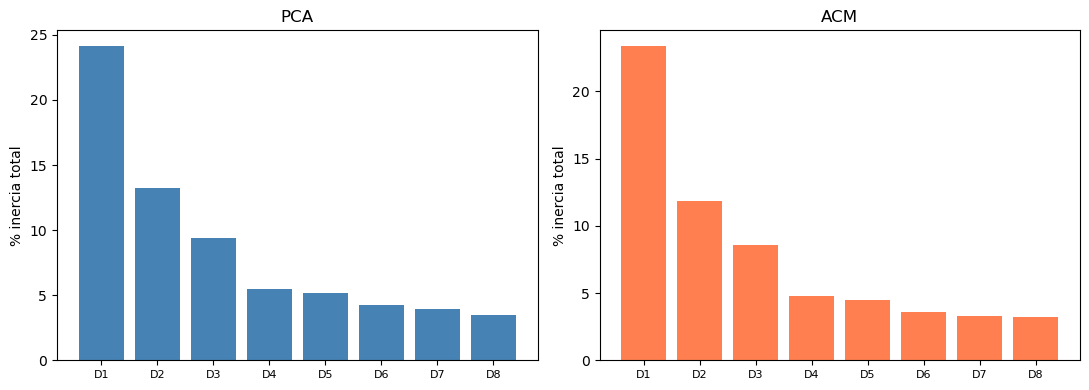

In [ ]:
fx.plot_scree()

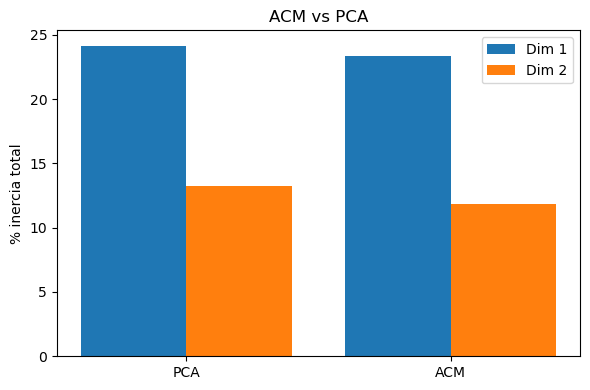

In [ ]:
fx.plot_comparison()

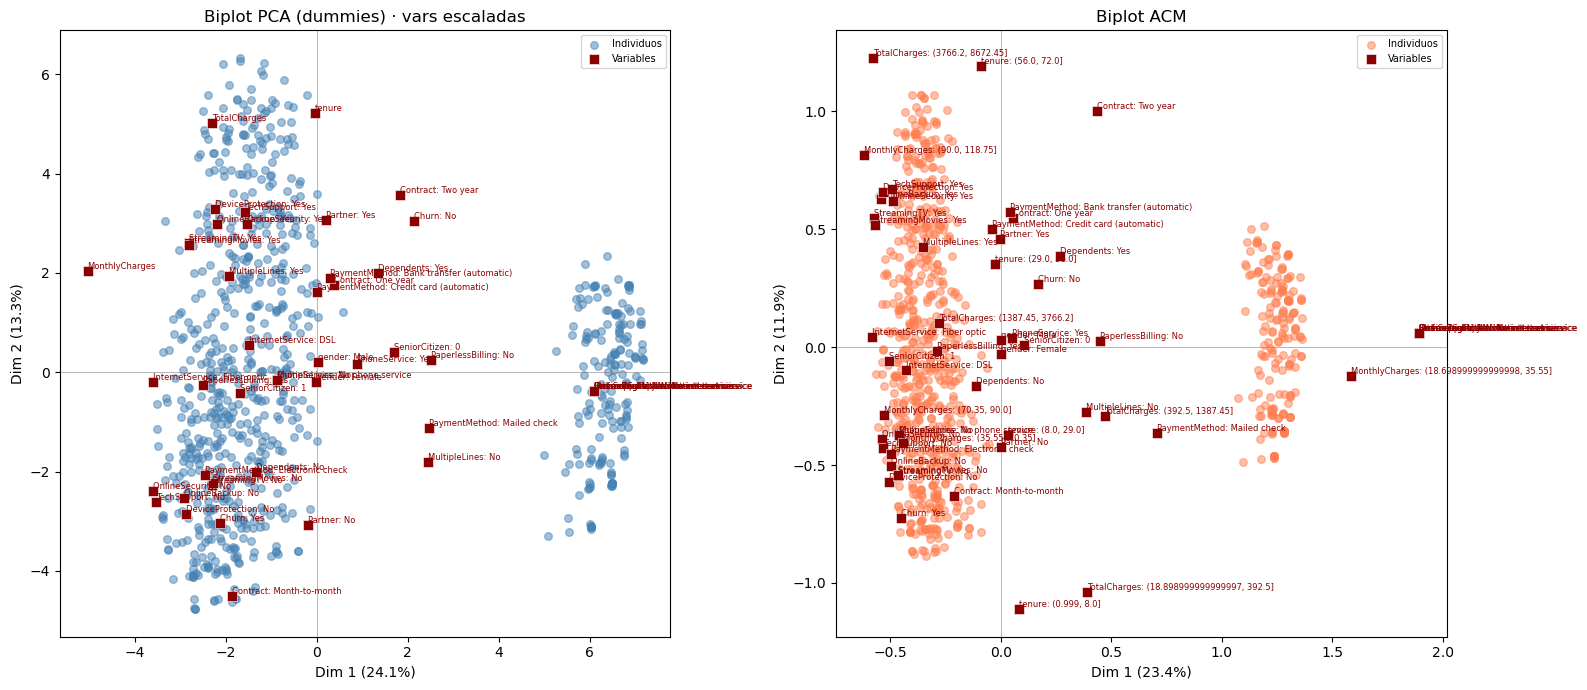

In [ ]:
fx.plot_biplots()

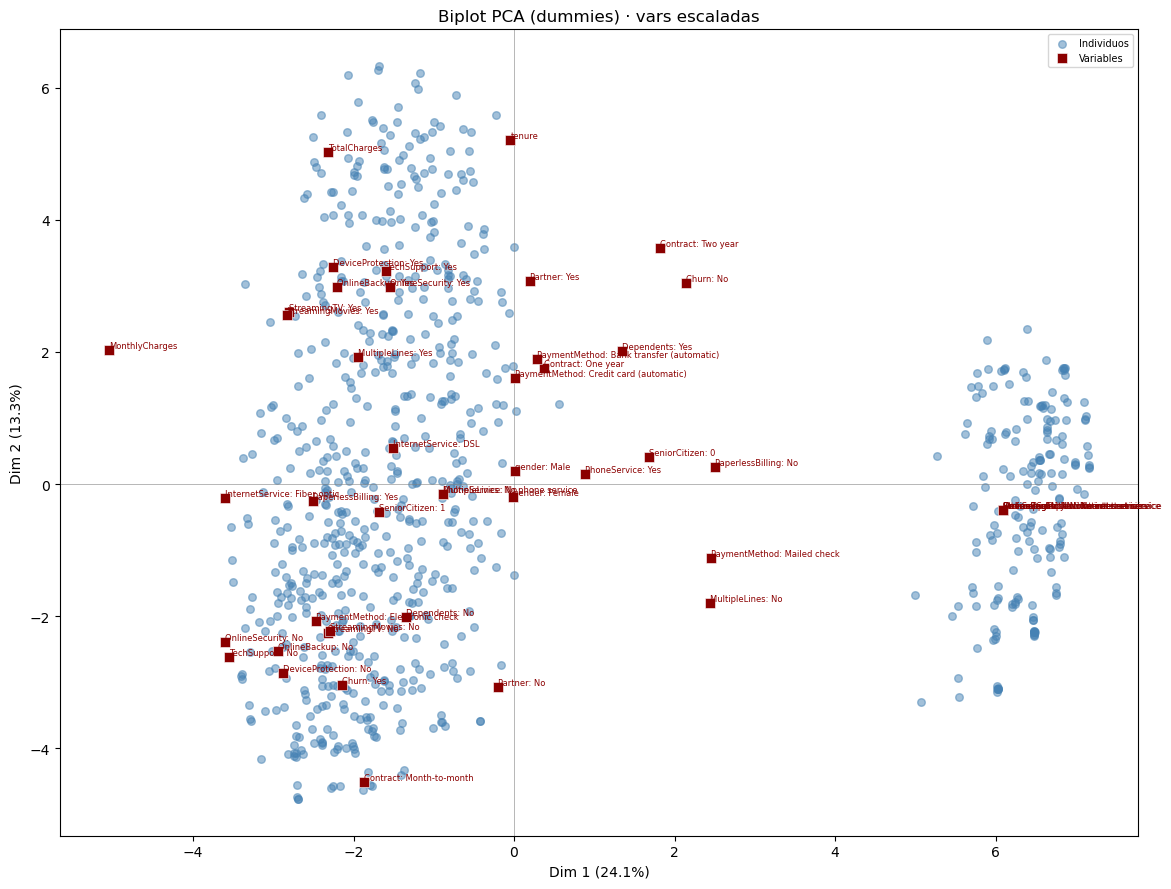

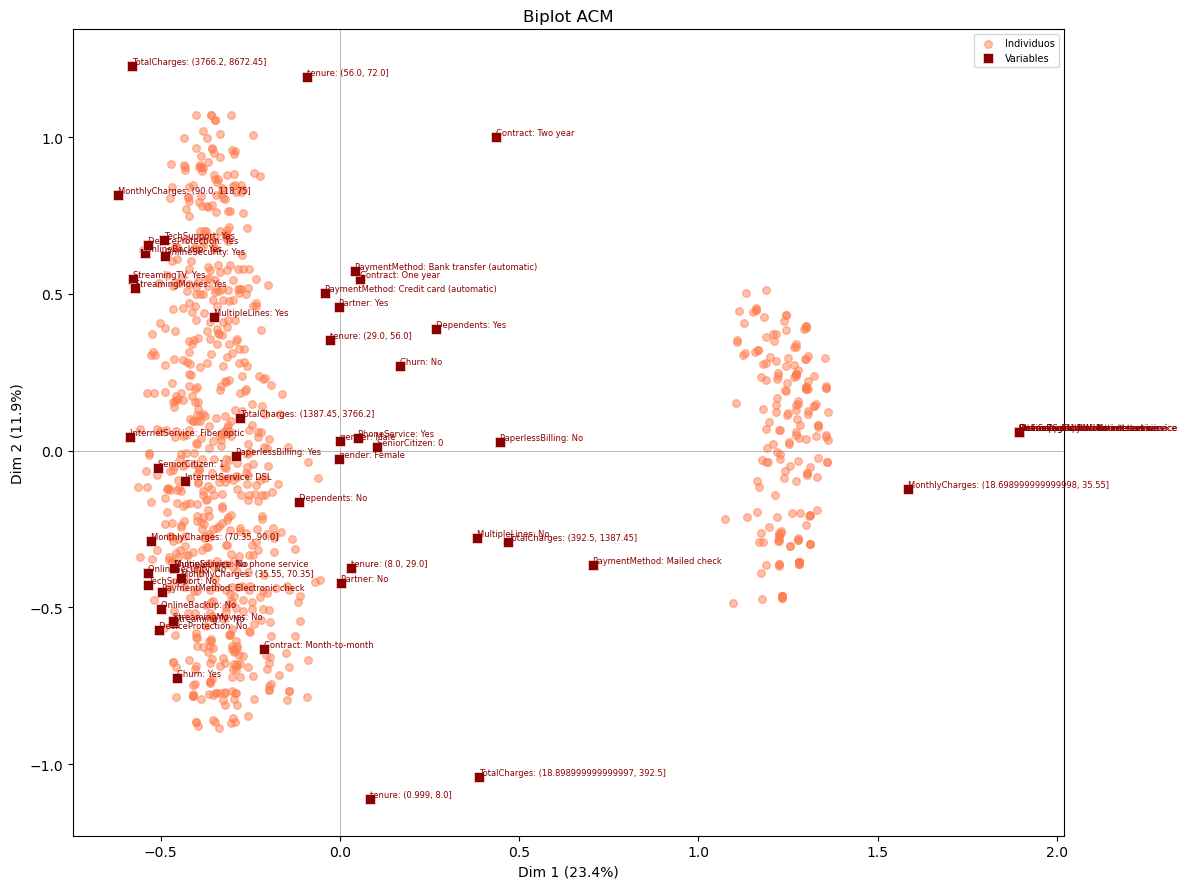

In [ ]:
fx.plot_biplots(individual=True)

In [ ]:
fx.show_contrib_cos2(n=12)

Contribuciones de variables (dims 1-2): PCA vs ACM


,PCA_variable,PCA_contrib,ACM_variable,ACM_contrib
rank,,,,
1,TotalCharges,0.1135,"TotalCharges: (3766.2, 8672.45]",0.0954
2,tenure,0.1094,InternetService: No,0.0892
3,Contract: Month-to-month,0.0895,StreamingMovies: No internet service,0.0892
4,InternetService: No,0.0827,OnlineBackup: No internet service,0.0892
5,OnlineSecurity: No internet service,0.0827,DeviceProtection: No internet service,0.0892
6,OnlineBackup: No internet service,0.0827,TechSupport: No internet service,0.0892
7,DeviceProtection: No internet service,0.0827,StreamingTV: No internet service,0.0892
8,TechSupport: No internet service,0.0827,OnlineSecurity: No internet service,0.0892
9,StreamingTV: No internet service,0.0827,"tenure: (56.0, 72.0]",0.0784


Resumen cos² de individuos en el plano 1-2


,metodo,cos2_media,cos2_mediana,cos2_min,pct_cos2>=0.5
0,PCA,0.3523,0.2857,0.0001,29.1938
1,ACM,0.3294,0.2515,0.0024,27.2409


Top 12 individuos por cos²: PCA vs ACM


,PCA_individuo,PCA_cos2,ACM_individuo,ACM_cos2
rank,,,,
1,3206,0.8410,3206,0.8036
2,3379,0.8409,3379,0.8036
3,367,0.8408,6140,0.8036
4,6140,0.8407,367,0.8036
5,5595,0.8407,4817,0.8036
6,2592,0.8406,4172,0.8036
7,4172,0.8406,121,0.8036
8,121,0.8405,509,0.8036
9,509,0.8403,6576,0.8036
